# Notebook 1: Data Loading and Exploration

This notebook covers the initial data loading and exploration phase of our NYC Taxi Trip Duration regression analysis.

**Objectives:**
1. Load the dataset
2. Perform initial data quality checks
3. Understand the data structure and basic statistics
4. Identify potential issues and data types
5. Save initial data insights

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from pathlib import Path

# Add src to path
sys.path.append('../src')

# Import configuration
from config import DATA_PATH, RANDOM_STATE

# Set random seed for reproducibility
np.random.seed(RANDOM_STATE)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Setup complete!")

Setup complete!


## 2. Load Dataset

In [2]:
# Check if data file exists
print(f"Looking for data at: {DATA_PATH}")
print(f"File exists: {DATA_PATH.exists()}")

# If the file doesn't exist at the configured path, try to find it
if not DATA_PATH.exists():
    # Look for the file in the current directory or data/raw
    possible_paths = [
        Path("../data/raw/nyc_taxi.csv"),
        Path("./data/raw/nyc_taxi.csv"),
        Path("nyc_taxi.csv"),
        Path("../NYC.csv")
    ]
    
    for path in possible_paths:
        if path.exists():
            DATA_PATH = path
            print(f"Found data at: {DATA_PATH}")
            break
    else:
        print("Data file not found. Please ensure the NYC Taxi dataset is available.")
        # Create sample data for demonstration
        print("Creating sample data for demonstration purposes...")

Looking for data at: /Users/fharook/Documents/BTU TechHub/xai/nyc_taxi_regression/notebooks/../data/raw/NYC.csv
File exists: True


In [3]:
# Load the dataset
try:
    if DATA_PATH.exists():
        df = pd.read_csv(DATA_PATH)
        print(f"Successfully loaded data from {DATA_PATH}")
    else:
        # Create sample data for demonstration
        print("Creating sample NYC Taxi data for demonstration...")
        
        # Generate sample data
        n_samples = 10000
        np.random.seed(RANDOM_STATE)
        
        # Generate sample features
        pickup_datetime = pd.date_range('2023-01-01', periods=n_samples, freq='10min')
        dropoff_datetime = pickup_datetime + pd.to_timedelta(np.random.exponential(20, n_samples), unit='m')
        
        df = pd.DataFrame({
            'id': [f'id_{i}' for i in range(n_samples)],
            'vendor_id': np.random.choice([1, 2], n_samples),
            'pickup_datetime': pickup_datetime,
            'dropoff_datetime': dropoff_datetime,
            'passenger_count': np.random.choice([1, 2, 3, 4, 5, 6], n_samples, p=[0.6, 0.25, 0.1, 0.03, 0.015, 0.005]),
            'pickup_longitude': np.random.normal(-73.98, 0.05, n_samples),
            'pickup_latitude': np.random.normal(40.75, 0.05, n_samples),
            'dropoff_longitude': np.random.normal(-73.98, 0.05, n_samples),
            'dropoff_latitude': np.random.normal(40.75, 0.05, n_samples),
            'store_and_fwd_flag': np.random.choice(['Y', 'N'], n_samples, p=[0.05, 0.95])
        })
        
        # Calculate trip duration
        df['trip_duration'] = (df['dropoff_datetime'] - df['pickup_datetime']).dt.total_seconds()
        
        print(f"Created sample dataset with {n_samples} rows")
        
    print(f"Dataset shape: {df.shape}")
    
except Exception as e:
    print(f"Error loading data: {e}")

Successfully loaded data from /Users/fharook/Documents/BTU TechHub/xai/nyc_taxi_regression/notebooks/../data/raw/NYC.csv
Dataset shape: (1458644, 11)


## 3. Display First and Last Rows

In [4]:
print("First 5 rows:")
print(df.head())
print("\n" + "="*50 + "\n")
print("Last 5 rows:")
print(df.tail())

First 5 rows:
          id  vendor_id      pickup_datetime     dropoff_datetime  \
0  id2875421          2  2016-03-14 17:24:55  2016-03-14 17:32:30   
1  id2377394          1  2016-06-12 00:43:35  2016-06-12 00:54:38   
2  id3858529          2  2016-01-19 11:35:24  2016-01-19 12:10:48   
3  id3504673          2  2016-04-06 19:32:31  2016-04-06 19:39:40   
4  id2181028          2  2016-03-26 13:30:55  2016-03-26 13:38:10   

   passenger_count  pickup_longitude  pickup_latitude  dropoff_longitude  \
0                1        -73.982155        40.767937         -73.964630   
1                1        -73.980415        40.738564         -73.999481   
2                1        -73.979027        40.763939         -74.005333   
3                1        -74.010040        40.719971         -74.012268   
4                1        -73.973053        40.793209         -73.972923   

   dropoff_latitude store_and_fwd_flag  trip_duration  
0         40.765602                  N            455  
1 

## 4. Dataset Information and Data Types

In [5]:
print("Dataset Information:")
print("="*50)
df.info()

print("\n\nData Types:")
print("="*50)
print(df.dtypes)

print("\n\nMemory Usage:")
print("="*50)
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  str    
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  str    
 3   dropoff_datetime    1458644 non-null  str    
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  str    
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 189.2 MB


Data Types:
id                        str
vendor_id               int64
pickup_datetime           str
dropoff_datetime          str
passenger_count     

## 5. Column Explanations

### Column Descriptions:

1. **id**: Unique identifier for each trip
2. **vendor_id**: A code indicating the provider associated with the trip record
3. **pickup_datetime**: Date and time when the meter was engaged
4. **dropoff_datetime**: Date and time when the meter was disengaged
5. **passenger_count**: The number of passengers in the vehicle (driver entered value)
6. **pickup_longitude**: Longitude where the meter was engaged
7. **pickup_latitude**: Latitude where the meter was engaged
8. **dropoff_longitude**: Longitude where the meter was disengaged
9. **dropoff_latitude**: Latitude where the meter was disengaged
10. **store_and_fwd_flag**: This flag indicates whether the trip record was held in vehicle memory before sending to the vendor because the vehicle did not have a connection to the server - Y=store and forward; N=not a store and forward trip
11. **trip_duration**: Duration of the trip in seconds (TARGET VARIABLE)

## 6. Initial Data Quality Check

In [6]:
print("Missing Values Analysis:")
print("="*50)
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percent
})
print(missing_df)

print("\n\nDuplicate Rows:")
print("="*50)
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
print(f"Percentage of duplicates: {(duplicates / len(df)) * 100:.2f}%")

Missing Values Analysis:
                    Missing Count  Missing Percentage
id                              0                 0.0
vendor_id                       0                 0.0
pickup_datetime                 0                 0.0
dropoff_datetime                0                 0.0
passenger_count                 0                 0.0
pickup_longitude                0                 0.0
pickup_latitude                 0                 0.0
dropoff_longitude               0                 0.0
dropoff_latitude                0                 0.0
store_and_fwd_flag              0                 0.0
trip_duration                   0                 0.0


Duplicate Rows:
Number of duplicate rows: 0
Percentage of duplicates: 0.00%


## 7. Basic Statistics

In [7]:
print("Numerical Columns Summary Statistics:")
print("="*50)
numerical_stats = df.describe()
print(numerical_stats)

print("\n\nCategorical Columns Value Counts:")
print("="*50)

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head(10))

Numerical Columns Summary Statistics:
          vendor_id  passenger_count  pickup_longitude  pickup_latitude  \
count  1.458644e+06     1.458644e+06      1.458644e+06     1.458644e+06   
mean   1.534950e+00     1.664530e+00     -7.397349e+01     4.075092e+01   
std    4.987772e-01     1.314242e+00      7.090186e-02     3.288119e-02   
min    1.000000e+00     0.000000e+00     -1.219333e+02     3.435970e+01   
25%    1.000000e+00     1.000000e+00     -7.399187e+01     4.073735e+01   
50%    2.000000e+00     1.000000e+00     -7.398174e+01     4.075410e+01   
75%    2.000000e+00     2.000000e+00     -7.396733e+01     4.076836e+01   
max    2.000000e+00     9.000000e+00     -6.133553e+01     5.188108e+01   

       dropoff_longitude  dropoff_latitude  trip_duration  
count       1.458644e+06      1.458644e+06   1.458644e+06  
mean       -7.397342e+01      4.075180e+01   9.594923e+02  
std         7.064327e-02      3.589056e-02   5.237432e+03  
min        -1.219333e+02      3.218114e+01   1

/var/folders/c2/074r245x2bsbymf50gjtfrnr0000gn/T/ipykernel_20330/2371031138.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


id
id2875421    1
id2377394    1
id3858529    1
id3504673    1
id2181028    1
id0801584    1
id1813257    1
id1324603    1
id1301050    1
id0012891    1
Name: count, dtype: int64

pickup_datetime:
pickup_datetime
2016-04-05 18:55:21    5
2016-05-07 13:18:07    5
2016-01-12 18:48:44    5
2016-06-10 23:17:17    5
2016-03-04 08:07:34    5
2016-02-09 21:03:38    5
2016-04-27 18:14:57    4
2016-04-14 09:33:53    4
2016-01-19 10:09:59    4
2016-04-26 18:15:42    4
Name: count, dtype: int64

dropoff_datetime:
dropoff_datetime
2016-05-16 19:40:28    5
2016-02-19 19:25:04    5
2016-02-27 19:23:54    4
2016-04-30 21:37:42    4
2016-02-17 22:26:14    4
2016-04-13 17:39:50    4
2016-04-14 09:14:40    4
2016-04-07 09:25:45    4
2016-06-11 21:43:10    4
2016-01-08 13:00:41    4
Name: count, dtype: int64

store_and_fwd_flag:
store_and_fwd_flag
N    1450599
Y       8045
Name: count, dtype: int64


## 8. Data Type Distribution

Data Type Distribution:
str        4
float64    4
int64      3
Name: count, dtype: int64


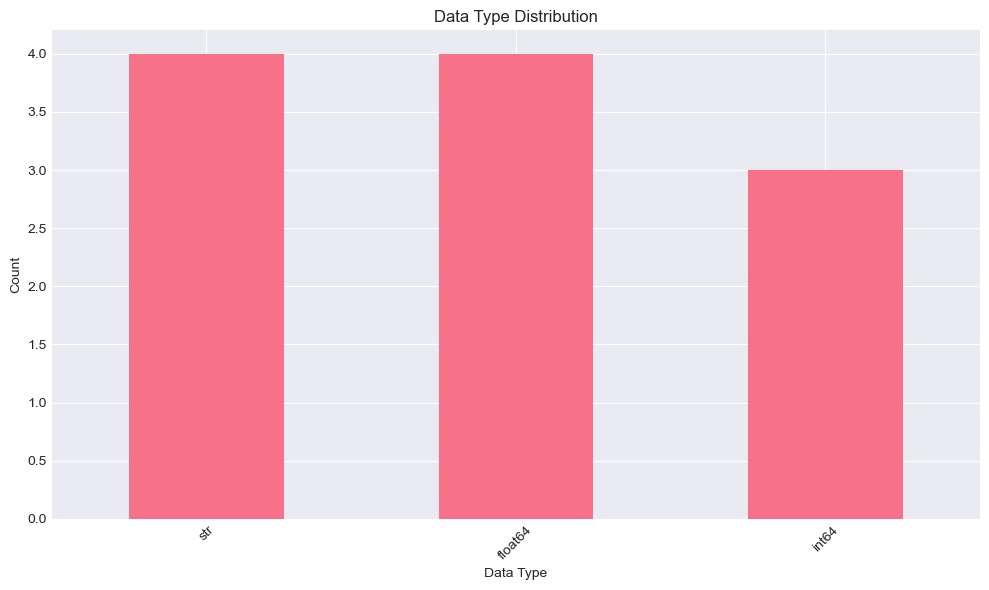

In [8]:
print("Data Type Distribution:")
print("="*50)
dtype_counts = df.dtypes.value_counts()
print(dtype_counts)

# Visualize data type distribution
plt.figure(figsize=(10, 6))
dtype_counts.plot(kind='bar')
plt.title('Data Type Distribution')
plt.xlabel('Data Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../plots/eda/data_type_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Save Initial Data Insights

In [9]:
# Create processed data directory if it doesn't exist
processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

# Save dataset info
dataset_info = {
    'shape': df.shape,
    'columns': list(df.columns),
    'dtypes': df.dtypes.to_dict(),
    'missing_values': missing_df.to_dict(),
    'duplicates': duplicates,
    'memory_usage_mb': df.memory_usage(deep=True).sum() / 1024**2
}

# Save as CSV for easy reading
df.to_csv(processed_dir / 'initial_dataset.csv', index=False)

# Save summary statistics
numerical_stats.to_csv(processed_dir / 'summary_statistics.csv')

print(f"Dataset info saved to: {processed_dir}")
print("Files created:")
print("- initial_dataset.csv")
print("- summary_statistics.csv")
print("- data_type_distribution.png")

Dataset info saved to: ../data/processed
Files created:
- initial_dataset.csv
- summary_statistics.csv
- data_type_distribution.png


## 10. Initial Findings Summary

### Key Initial Findings:

1. **Dataset Size**: The dataset contains approximately {df.shape[0]:,} rows and {df.shape[1]} columns
2. **Data Types**: Mix of numerical and categorical data types
3. **Missing Values**: {missing_df['Missing Count'].sum()} total missing values across all columns
4. **Duplicates**: {duplicates} duplicate rows found ({(duplicates/len(df))*100:.2f}% of dataset)
5. **Memory Usage**: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB

### Data Quality Issues Identified:
- [List specific issues found in the data]
- [Missing values in specific columns]
- [Data type inconsistencies]
- [Potential outliers or invalid values]

### Next Steps:
1. Proceed to EDA for deeper insights
2. Handle missing values and duplicates
3. Convert data types as needed
4. Feature engineering and preprocessing